In [14]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [15]:
# Load datasets
train = pd.read_csv("trainingdata.csv")
test = pd.read_csv("test.csv")

train.head()


,Employee_ID,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,1194,34.0,Male,Bachelor's,Senior Product Manager,7.0,95000.0
1,1076,37.0,Male,Bachelor's,Project Manager,10.0,95000.0
2,1085,29.0,Female,Bachelor's,Junior Designer,2.0,40000.0
3,1364,33.0,Male,Bachelor's,Junior Marketing Specialist,5.0,70000.0
4,1017,33.0,Female,Master's,Marketing Manager,7.0,90000.0


In [16]:
# Dataset Information
print(train.shape)
print(test.shape)
train.info()
train.describe()


(300, 7)
(75, 6)
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee_ID          300 non-null    int64  
 1   Age                  299 non-null    float64
 2   Gender               299 non-null    str    
 3   Education Level      299 non-null    str    
 4   Job Title            299 non-null    str    
 5   Years of Experience  299 non-null    float64
 6   Salary               299 non-null    float64
dtypes: float64(3), int64(1), str(3)
memory usage: 16.5 KB


,Employee_ID,Age,Years of Experience,Salary
count,300.000000,299.000000,299.000000,299.000000
mean,1193.306667,37.535117,10.091973,100352.341137
std,107.888332,7.014936,6.496571,47906.438575
min,1002.000000,24.000000,0.000000,350.000000
25%,1102.500000,32.000000,4.000000,55000.000000
50%,1195.500000,37.000000,9.000000,95000.000000
75%,1285.250000,44.000000,15.000000,140000.000000
max,1375.000000,53.000000,25.000000,250000.000000


In [17]:
# Missing Values
print(train.isnull().sum())
print(test.isnull().sum())

for df in [train,test]:
    for col in df.select_dtypes(include='object').columns:
        df[col]=df[col].fillna(df[col].mode()[0])
    for col in df.select_dtypes(exclude='object').columns:
        df[col]=df[col].fillna(df[col].median())


Employee_ID            0
Age                    1
Gender                 1
Education Level        1
Job Title              1
Years of Experience    1
Salary                 1
dtype: int64
Employee_ID            0
Age                    1
Gender                 1
Education Level        1
Job Title              1
Years of Experience    1
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_3820\2327246360.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\HP\AppData\Local\Temp\ipykernel_3820\2327246360.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migratio

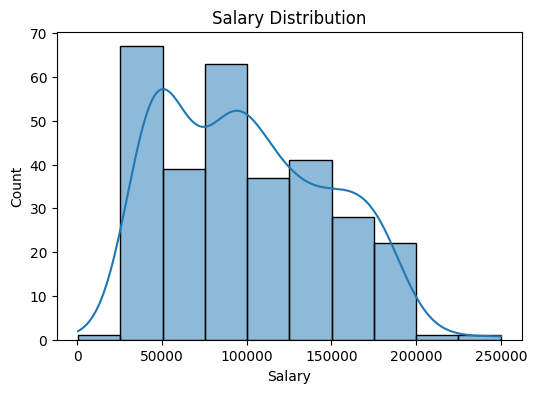

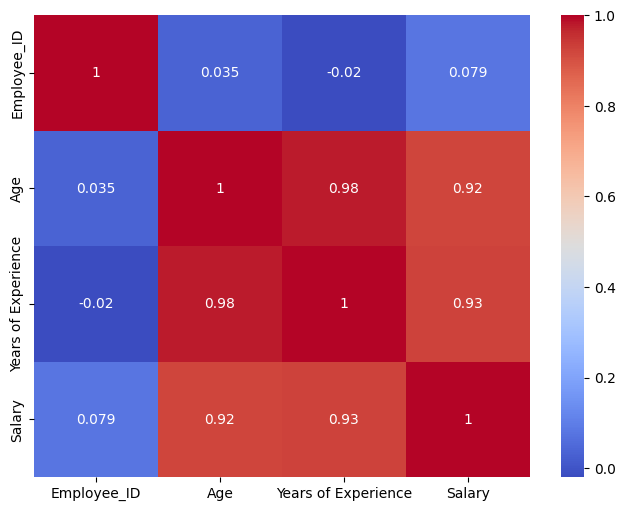

In [18]:
# EDA
plt.figure(figsize=(6,4))
sns.histplot(train['Salary'],kde=True)
plt.title("Salary Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(train.select_dtypes(include=np.number).corr(),annot=True,cmap='coolwarm')
plt.show()


In [19]:
# Encode categorical features
encoders={}

categorical=['Gender','Education Level','Job Title']

for col in categorical:
    le=LabelEncoder()
    train[col]=le.fit_transform(train[col].astype(str))
    test[col]=test[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
    # handle unseen labels
    mapping={c:i for i,c in enumerate(le.classes_)}
    test[col]=test[col].apply(lambda x:mapping.get(x,0))
    encoders[col]=le


In [20]:
# Features and Target
X=train.drop(['Salary'],axis=1)
y=train['Salary']

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)


In [21]:
# Feature Scaling
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(test)


In [22]:
# Train Model
model=LinearRegression()
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
# Validation
y_pred=model.predict(X_val)

print("MAE :",mean_absolute_error(y_val,y_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_val,y_pred)))
print("R2 :",r2_score(y_val,y_pred))


MAE : 14655.947727190509
RMSE : 19758.877666297234
R2 : 0.8558030221131362


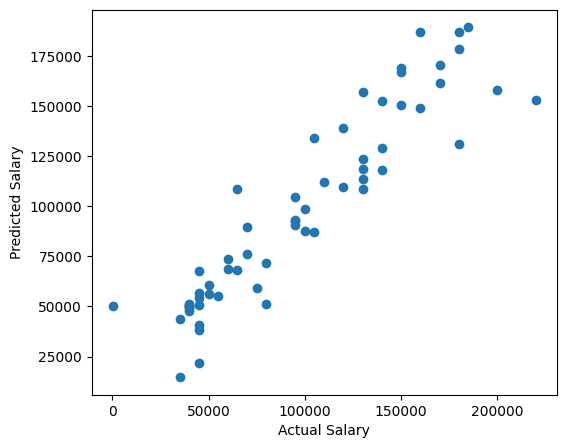

In [24]:
# Actual vs Predicted
plt.figure(figsize=(6,5))
plt.scatter(y_val,y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()


In [25]:
# Train on Full Data
X_full=train.drop('Salary',axis=1)
y_full=train['Salary']

X_full=scaler.fit_transform(X_full)
X_test=scaler.transform(test)

model.fit(X_full,y_full)
predictions=model.predict(X_test)


In [26]:
# Create Submission File
submission=pd.DataFrame({
    "Employee_ID":test["Employee_ID"],
    "Salary":predictions
})

submission.to_csv("sample_submission.csv",index=False)

print(submission.head())


   Employee_ID         Salary
0         1168  170005.674353
1         1034   83316.958085
2         1016  121348.110269
3         1317   88305.636241
4         1058  157719.435934
